# Delay propagation at Dubai International (DXB)

**Question:** when a flight lands late at DXB, how much of that delay does the
next flight on the same aircraft inherit — and what stops it?

**Data:** 510,000 arrival and departure records from Dubai Airports, May 2025
to September 2026, loaded into PostgreSQL and paired into 230,928 aircraft
turnarounds.

**Answer in one line:** a minute of arrival delay becomes 0.65 minutes of
departure delay on average, but that figure hides two completely different
operations — foreign carriers pass through 93% of it, Emirates and Flydubai
only 27%, and the difference is scheduled ground time.

Pipeline: `sql/01` to `sql/06` build the database tables this notebook reads.

In [1]:
import sys
sys.path.append("../python")
from db import read_sql, FIG_DIR, PROCESSED_DIR

ModuleNotFoundError: No module named 'pandas'

In [3]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "python"))   # notebook lives in dxb_ops/notebooks/
from db import FIG_DIR, PROCESSED_DIR, read_sql

ModuleNotFoundError: No module named 'pandas'

In [2]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from db import FIG_DIR, PROCESSED_DIR, read_sql

FIG_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

ModuleNotFoundError: No module named 'matplotlib'

## 1. Load the turnarounds

Every row is one aircraft turnaround: it landed, sat on a stand, and left
again. Turns longer than six hours are dropped — past that the aircraft is
parked overnight and the next departure is its own story, not a consequence of
the arrival.

In [56]:
turns = read_sql(
    """
    SELECT arr_key, dep_key, registration, aircraft_type,
           airline_icao, airline_name, carrier_group,
           terminal_changed, arr_hour, arr_dow, turn_date,
           sched_ground_min, actual_ground_min, ground_variance,
           arr_delay_min, dep_delay_min, delay_recovered,
           arr_delayed_15, dep_delayed_15, is_propagated,
           turn_band, arr_delay_band, coverage_complete
    FROM analytics.turnarounds
    WHERE actual_ground_min < 360
    """
)
# Postgres NUMERIC columns can arrive as Python Decimal objects depending on
# the driver; force them to float so the filters and the regression behave.
num_cols = ["sched_ground_min", "actual_ground_min", "ground_variance",
            "arr_delay_min", "dep_delay_min", "delay_recovered"]
turns[num_cols] = turns[num_cols].apply(pd.to_numeric)
turns["arr_hour"] = pd.to_numeric(turns["arr_hour"]).astype(int)

if turns.empty:
    raise RuntimeError(
        "analytics.turnarounds returned 0 rows. Check the table exists in pgAdmin "
        "(SELECT COUNT(*) FROM analytics.turnarounds) and that .env points at the same database."
    )
print(f"{len(turns):,} turns under 6 hours loaded")
print(turns[["sched_ground_min", "actual_ground_min", "arr_delay_min", "dep_delay_min"]].describe().round(1))

190,579 turns under 6 hours loaded
       sched_ground_min  actual_ground_min  arr_delay_min  dep_delay_min
count          190579.0           190579.0       190579.0       190579.0
mean              134.1              144.6            7.5           18.0
std                77.4               74.8           44.2           38.7
min              -445.0               26.6          -60.0          -50.3
25%                75.0               83.8          -12.8            1.6
50%               115.0              124.5           -1.7            8.2
75%               175.0              188.5           13.6           19.4
max               810.0              359.9          599.5          598.9


190,579 turns load, about 82% of all pairs. Median scheduled ground time is 115
minutes, median actual 124: the typical turn at DXB runs about nine minutes
longer than planned.

In [35]:
print(read_sql("SELECT current_database() AS db, inet_server_port() AS port"))
print(read_sql("""
    SELECT 'movements' AS t, COUNT(*) AS n FROM analytics.movements
    UNION ALL SELECT 'turnarounds', COUNT(*) FROM analytics.turnarounds
"""))

        db  port
0  dxb_ops  5432
             t       n
0  turnarounds  230928
1    movements  509382


## 2. How steep is the cascade?

Bin every arrival by how late it was, then ask what share of the following
departures left 15 or more minutes behind schedule. The dashed line at 15% is
roughly the rate you would see if arrival delay had no effect at all.

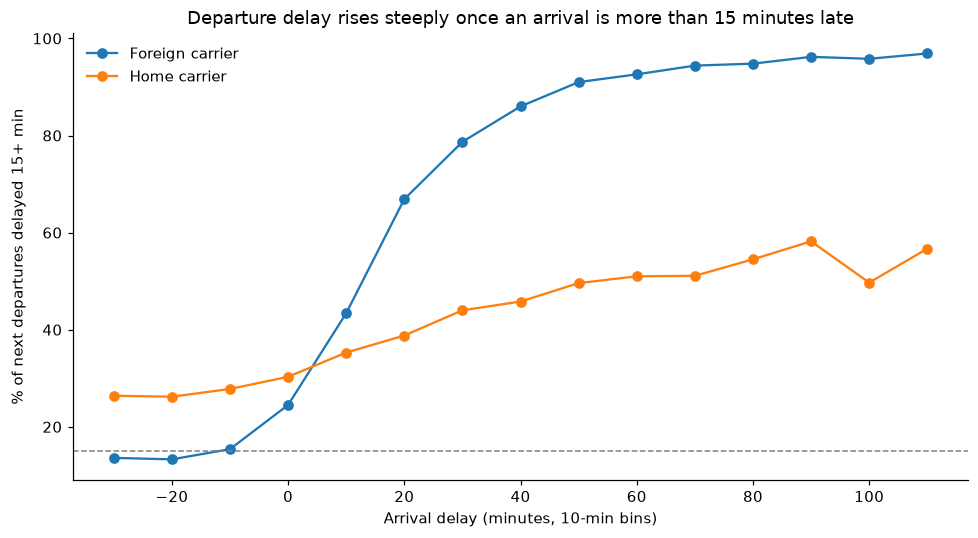

carrier_group  Foreign carrier  Home carrier
bin_start                                   
-30                       13.6          26.4
-20                       13.3          26.2
-10                       15.4          27.8
 0                        24.5          30.3
 10                       43.4          35.3
 20                       66.9          38.8
 30                       78.7          44.0
 40                       86.0          45.8
 50                       91.0          49.6
 60                       92.6          51.0
 70                       94.4          51.1
 80                       94.8          54.5
 90                       96.2          58.2
 100                      95.8          49.7
 110                      96.9          56.7


In [55]:
bins = list(range(-30, 130, 10))
turns["arr_bin"] = pd.cut(turns["arr_delay_min"].clip(-30, 129), bins=bins, right=False)

curve = (
    turns.groupby(["carrier_group", "arr_bin"], observed=True)
    .agg(turns=("dep_key", "size"), pct_dep_delayed=("dep_delayed_15", "mean"), avg_dep_delay=("dep_delay_min", "mean"))
    .reset_index()
)
curve["pct_dep_delayed"] = (100 * curve["pct_dep_delayed"]).round(1)
curve["bin_start"] = curve["arr_bin"].apply(lambda b: b.left)
curve.to_csv(PROCESSED_DIR / "cascade_curve.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
for grp, sub in curve.groupby("carrier_group"):
    sub = sub[sub["turns"] >= 200]
    ax.plot(sub["bin_start"], sub["pct_dep_delayed"], marker="o", label=grp)
ax.axhline(15, ls="--", lw=1, color="grey")
ax.set_xlabel("Arrival delay (minutes, 10-min bins)")
ax.set_ylabel("% of next departures delayed 15+ min")
ax.set_title("Departure delay rises steeply once an arrival is more than 15 minutes late")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_cascade_curve.png")
plt.show()

print(curve.pivot(index="bin_start", columns="carrier_group", values="pct_dep_delayed").to_string())

The two curves tell completely different stories.

For foreign carriers the cascade is close to total. A 20-minute late arrival
means a 67% chance the next departure is also late; past 40 minutes it is
essentially certain at 86% and rising to 95%.

Emirates and Flydubai flatten out around 50%. Even a 90-minute late arrival
leaves them better than even odds of departing on time.

The reason is in the schedule, not the ground crew: the home carriers plan a
median 150 minutes on the ground, foreign carriers 70.

## 3. How many minutes actually pass through?

The curve shows the shape; this gives the number. The model predicts departure
delay from arrival delay, scheduled ground time, carrier group and time of day,
so the pass-through figure holds the other three constant.

Arrival delay is split into "minutes late" and "minutes early" because they are
not opposites: arriving an hour early does not buy back an hour.

In [54]:
model_df = turns[(turns["dep_delay_min"].between(-60, 300)) & (turns["sched_ground_min"].between(20, 360))].copy()
model_df["arr_late"] = model_df["arr_delay_min"].clip(lower=0)
model_df["arr_early"] = (-model_df["arr_delay_min"]).clip(lower=0)
model_df["sched_ground_hr"] = model_df["sched_ground_min"] / 60
model_df["hour_band"] = pd.cut(
    model_df["arr_hour"], bins=[-1, 5, 11, 17, 23], labels=["Night 00-05", "Morning 06-11", "Afternoon 12-17", "Evening 18-23"]
)

if model_df.empty:
    raise RuntimeError("No rows left after the plausibility filter; inspect turns[['dep_delay_min','sched_ground_min']].describe().")
print(f"{len(model_df):,} turns in the regression sample")

ols = smf.ols(
    "dep_delay_min ~ arr_late + arr_early + sched_ground_hr + C(carrier_group) + C(hour_band) + C(terminal_changed)",
    data=model_df,
).fit(cov_type="HC1")
print(ols.summary().tables[1])
print(f"\nR-squared: {ols.rsquared:.3f}  |  n = {int(ols.nobs):,}")

coef = ols.params
print(
    f"\nEach minute of arrival delay adds {coef['arr_late']:.2f} min of departure delay, "
    f"and each extra scheduled hour on the ground removes {-coef['sched_ground_hr']:.1f} min."
)

# Propagation coefficient per carrier group (separate fits)
rows = []
for grp, sub in model_df.groupby("carrier_group"):
    m = smf.ols("dep_delay_min ~ arr_late + arr_early + sched_ground_hr + C(hour_band)", data=sub).fit()
    rows.append({"carrier_group": grp, "n": int(m.nobs), "passthrough_per_min": round(m.params["arr_late"], 3), "r2": round(m.rsquared, 3)})
passthrough = pd.DataFrame(rows)
print(passthrough.to_string(index=False))
passthrough.to_csv(PROCESSED_DIR / "passthrough_by_carrier_group.csv", index=False)

187,522 turns in the regression sample
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           19.4392      0.213     91.289      0.000      19.022      19.857
C(carrier_group)[T.Home carrier]     3.1001      0.136     22.758      0.000       2.833       3.367
C(hour_band)[T.Morning 06-11]       -3.0286      0.166    -18.267      0.000      -3.354      -2.704
C(hour_band)[T.Afternoon 12-17]     -9.3427      0.168    -55.622      0.000      -9.672      -9.013
C(hour_band)[T.Evening 18-23]       -5.3800      0.159    -33.836      0.000      -5.692      -5.068
C(terminal_changed)[T.True]         -3.3584      0.213    -15.794      0.000      -3.775      -2.942
arr_late                             0.6451      0.005    117.916      0.000       0.634       0.656
arr_early                            0.0972      0.0

Each minute of arrival delay adds 0.65 minutes to the departure, and each extra
hour of scheduled ground time removes 4.2 minutes. Afternoon turns run about 9
minutes better than overnight ones.

Splitting the model by carrier group is where it gets interesting: foreign
carriers pass through 0.93 minutes per minute — almost all of it — while
Emirates and Flydubai pass through 0.27.

That is the headline finding. Two airlines operating in the same airport, the
same weather and the same airspace, with a three-fold difference in how much
delay survives the turn.

## 4. How much ground time is enough?

The regression says buffer absorbs delay. This turns that into a number an
operations planner can use: take only the turns where the aircraft arrived more
than 15 minutes late, group them by how much ground time was scheduled, and see
how often the departure still went out late.

            turns  avg_arr_delay  avg_dep_delay  pct_dep_delayed  avg_recovered  pct_recovered
sched_bin                                                                                     
[30, 60)     1530           51.6           69.3            100.0          -17.7          -34.3
[60, 90)    11516           66.7           74.5             90.0           -7.8          -11.7
[90, 120)    8280           45.8           38.1             60.0            7.7           16.8
[120, 150)   6239           42.6           27.2             50.0           15.5           36.4
[150, 180)   4461           41.6           21.3             40.0           20.3           48.8
[180, 240)   5555           49.7           19.9             40.0           29.7           59.8
[240, 300)   3250           57.7           18.4             40.0           39.3           68.1


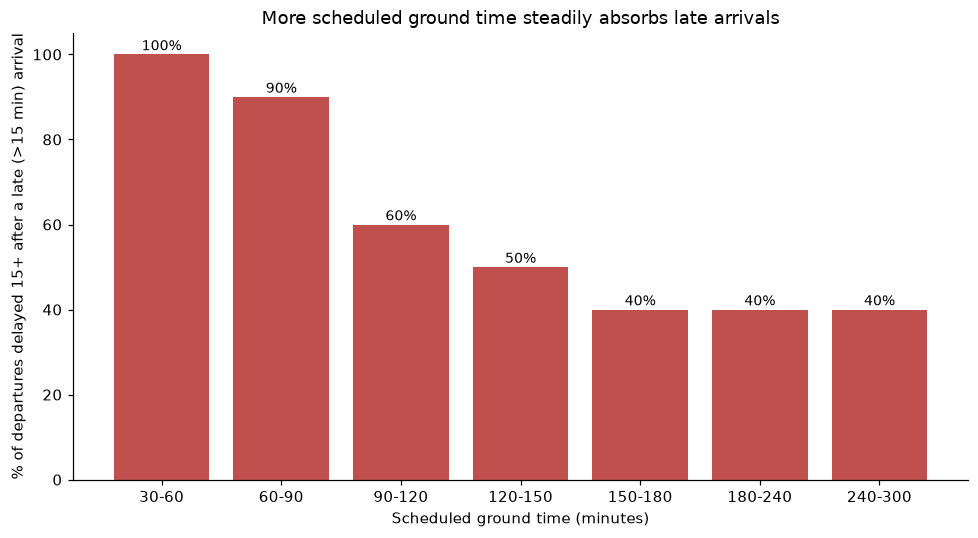

In [53]:
late = turns[(turns["arr_delay_min"] > 15) & (turns["sched_ground_min"].between(30, 300))].copy()
late["sched_bin"] = pd.cut(late["sched_ground_min"], bins=[30, 60, 90, 120, 150, 180, 240, 300], right=False)

buffer_tbl = (
    late.groupby("sched_bin", observed=True)
    .agg(
        turns=("dep_key", "size"),
        avg_arr_delay=("arr_delay_min", "mean"),
        avg_dep_delay=("dep_delay_min", "mean"),
        pct_dep_delayed=("dep_delayed_15", "mean"),
        avg_recovered=("delay_recovered", "mean"),
    )
    .round(1)
)
buffer_tbl["pct_dep_delayed"] = (100 * buffer_tbl["pct_dep_delayed"]).round(1)
buffer_tbl["pct_recovered"] = (100 * buffer_tbl["avg_recovered"] / buffer_tbl["avg_arr_delay"]).round(1)
print(buffer_tbl.to_string())
buffer_tbl.reset_index().to_csv(PROCESSED_DIR / "buffer_vs_recovery.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(buffer_tbl))
ax.bar(x, buffer_tbl["pct_dep_delayed"], color="#c0504d")
ax.set_xticks(x, [f"{int(i.left)}-{int(i.right)}" for i in buffer_tbl.index])
ax.set_xlabel("Scheduled ground time (minutes)")
ax.set_ylabel("% of departures delayed 15+ after a late (>15 min) arrival")
ax.set_title("More scheduled ground time steadily absorbs late arrivals")
for i, v in enumerate(buffer_tbl["pct_dep_delayed"]):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_buffer_vs_delay.png")
plt.show()

The recovery curve is steep up to two hours and then flattens.

With 60 to 90 minutes scheduled, a late arrival stays late 90% of the time and
the turn actually loses a further 8 minutes. At 120 to 150 minutes the rate
falls to 50% and the crew claws back about 15 minutes. Past 180 minutes it
settles around 40%, and that floor does not move.

The practical reading: the first extra hour of buffer is worth a great deal,
the second is worth much less, and no amount of buffer gets a carrier below
about 40% because that residual is delay generated on the ground at DXB rather
than inherited from the inbound flight.

## 5. Inherited delay or self-inflicted?

Two airlines can have the same on-time record for opposite reasons: one keeps
receiving late aircraft, the other is slow on the ground. This separates them.

For each airline, compare departures that followed an on-time arrival — where
any delay was created at DXB — against those that followed a late arrival,
where it was inherited. The first number is a ground-performance score. The gap
between them is how much slack the schedule has.

                                 turns_after_late_arrival  turns_after_ontime_arrival  pct_dep_delayed_after_late_arrival  pct_dep_delayed_after_ontime_arrival  recovery_gap
airline_name                                                                                                                                                                 
Himalaya Airlines                                   105.0                       304.0                                99.0                                  44.1          54.9
Pobeda                                              174.0                       322.0                                90.8                                  32.9          57.9
Egypt Air                                           650.0                       774.0                                87.7                                  32.7          55.0
Air Astana                                          250.0                       472.0                                92.0         

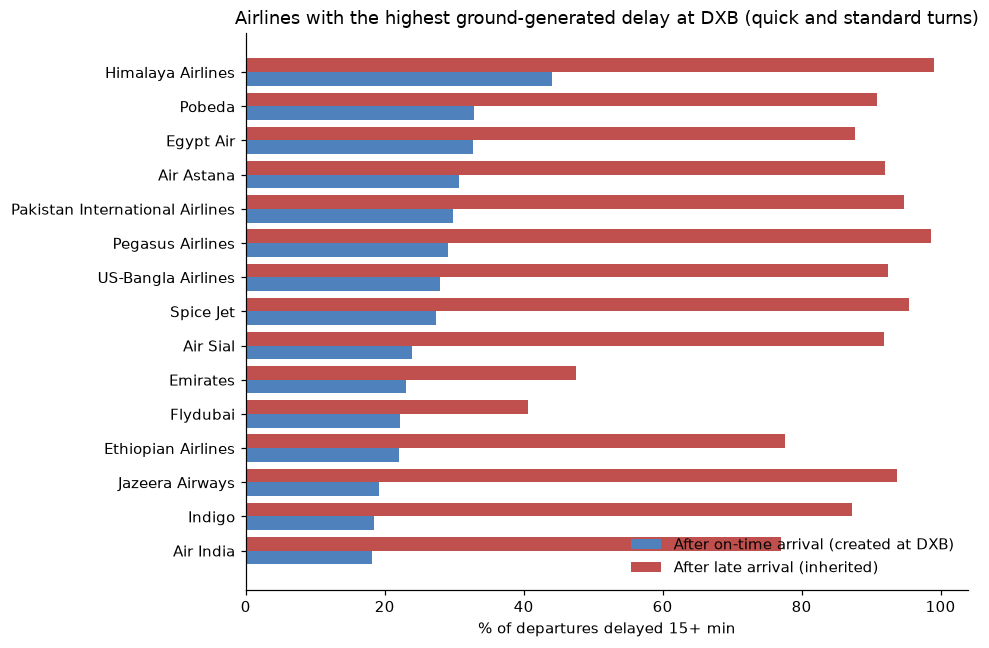

In [52]:
quick = turns[turns["turn_band"].isin(["Quick (<90)", "Standard (90-180)"])].copy()
quick["arrival_state"] = np.where(quick["arr_delay_min"] > 15, "after_late_arrival", "after_ontime_arrival")

airline_tbl = (
    quick.groupby(["airline_name", "arrival_state"])
    .agg(turns=("dep_key", "size"), pct_dep_delayed=("dep_delayed_15", "mean"))
    .reset_index()
)
airline_tbl["pct_dep_delayed"] = (100 * airline_tbl["pct_dep_delayed"]).round(1)
wide = airline_tbl.pivot(index="airline_name", columns="arrival_state", values=["turns", "pct_dep_delayed"])
wide.columns = [f"{a}_{b}" for a, b in wide.columns]
wide = wide[(wide["turns_after_ontime_arrival"] >= 300) & (wide["turns_after_late_arrival"] >= 100)].copy()
wide["recovery_gap"] = (wide["pct_dep_delayed_after_late_arrival"] - wide["pct_dep_delayed_after_ontime_arrival"]).round(1)
wide = wide.sort_values("pct_dep_delayed_after_ontime_arrival", ascending=False)
print(wide.round(1).to_string())
wide.reset_index().to_csv(PROCESSED_DIR / "airline_baseline_vs_propagated.csv", index=False)

top = wide.head(15).sort_values("pct_dep_delayed_after_ontime_arrival")
fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(top))
ax.barh(y - 0.2, top["pct_dep_delayed_after_ontime_arrival"], height=0.4, label="After on-time arrival (created at DXB)", color="#4f81bd")
ax.barh(y + 0.2, top["pct_dep_delayed_after_late_arrival"], height=0.4, label="After late arrival (inherited)", color="#c0504d")
ax.set_yticks(y, top.index)
ax.set_xlabel("% of departures delayed 15+ min")
ax.set_title("Airlines with the highest ground-generated delay at DXB (quick and standard turns)")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_airline_baseline_vs_propagated.png")
plt.show()

The split resolves a puzzle from the SQL validation, where SpiceJet and Saudia
had similar ground times but wildly different delay rates.

SpiceJet departs late 27% of the time even when the aircraft arrived on time.
Saudia does so 6% of the time. That is a ground-process difference, not bad
luck with inbound flights.

Jazeera, Kuwait Airways and Air Blue show the opposite pattern: strong
baselines near 10 to 19%, but 90% or worse once an arrival runs late. Their
ground operation is fine; their schedules have no slack.

For Emirates and Flydubai the two bars sit close together (23% against 48%, 22%
against 41%), which is what a well-buffered hub is supposed to look like.

These are three different problems needing three different fixes: process for
the first group, schedule for the second, and for the third, the 22% baseline
is the target.

## 6. What this adds up to

The numbers below go in the README and the dashboard.

In [51]:
ontime_arr = turns[turns["arr_delay_min"] <= 0]
late_arr = turns[turns["arr_delay_min"] > 30]
summary = {
    "turns_analysed": len(turns),
    "pct_dep_delayed_after_ontime_arrival": round(100 * ontime_arr["dep_delayed_15"].mean(), 1),
    "pct_dep_delayed_after_30plus_late_arrival": round(100 * late_arr["dep_delayed_15"].mean(), 1),
    "passthrough_minutes_per_minute": round(coef["arr_late"], 2),
    "minutes_absorbed_per_scheduled_hour": round(-coef["sched_ground_hr"], 1),
    "median_sched_ground_home_carrier": turns.loc[turns["carrier_group"] == "Home carrier", "sched_ground_min"].median(),
    "median_sched_ground_foreign_carrier": turns.loc[turns["carrier_group"] == "Foreign carrier", "sched_ground_min"].median(),
}
pd.Series(summary).to_csv(PROCESSED_DIR / "cascade_headline_numbers.csv", header=False)
for k, v in summary.items():
    print(f"{k:45s} {v}")

turns_analysed                                190579
pct_dep_delayed_after_ontime_arrival          22.3
pct_dep_delayed_after_30plus_late_arrival     65.7
passthrough_minutes_per_minute                0.65
minutes_absorbed_per_scheduled_hour           4.2
median_sched_ground_home_carrier              150.0
median_sched_ground_foreign_carrier           70.0


## What this analysis cannot tell you

**No delay causes.** The data records that a flight was late, not why. Weather,
crew, ATC restrictions and cargo are all invisible here, so "created at DXB"
means "not inherited from the inbound aircraft", not "the airline's fault".

**Coverage gaps.** About 38% of the turns fall in months where the export is
incomplete — December 2025 is missing half its days, and March to August 2026
average 260 to 500 movements a day against a normal 620 to 660. Per-turn rates
are unaffected, but no count in this notebook should be read as a volume trend.
The `coverage_complete` flag marks the seven clean months.

**Average, not extreme.** The regression models a conditional mean. Disruption
days, which matter most operationally, sit in a tail it does not describe.

**Next step:** joining hourly weather for OMDB would separate weather delay
from process delay and remove the largest single confounder.